# Arabic to English Machine Translation

In [ ]:
#Imports
import os, re, json, math, warnings, random
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
from tqdm.auto import tqdm

import torch
from datasets import load_dataset, DatasetDict
from transformers import (
    MarianMTModel, MarianTokenizer,
    Seq2SeqTrainer, Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq, EarlyStoppingCallback
)
import evaluate
from bert_score import score as bert_score_fn

# Reproducibility 
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}')

#Global style
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans'
})
PALETTE = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800']

Device : cuda
PyTorch: 2.10.0+cu128


---
## 2. Data Loading

In [ ]:
print('Loading dataset...')
raw = load_dataset('Helsinki-NLP/opus-100', 'ar-en')
print(raw)

MAX_SAMPLES = 250_000

def cap_split(split, n):
    return split.shuffle(seed=SEED).select(range(min(n, len(split))))

train_raw = cap_split(raw['train'],      int(MAX_SAMPLES * 0.90))
val_raw   = cap_split(raw['validation'], int(MAX_SAMPLES * 0.05))
test_raw  = cap_split(raw['test'],       int(MAX_SAMPLES * 0.05))

print(f'Train : {len(train_raw):,}')
print(f'Val   : {len(val_raw):,}')
print(f'Test  : {len(test_raw):,}')

sample = train_raw[0]
print('\nSample translation pair:')
print('AR:', sample['translation']['ar'])
print('EN:', sample['translation']['en'])

Loading dataset...


README.md: 0.00B [00:00, ?B/s]

ar-en/test-00000-of-00001.parquet:   0%|          | 0.00/214k [00:00<?, ?B/s]

ar-en/train-00000-of-00001.parquet:   0%|          | 0.00/99.3M [00:00<?, ?B/s]

ar-en/validation-00000-of-00001.parquet:   0%|          | 0.00/979k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/1000000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    test: Dataset({
        features: ['translation'],
        num_rows: 2000
    })
    train: Dataset({
        features: ['translation'],
        num_rows: 1000000
    })
    validation: Dataset({
        features: ['translation'],
        num_rows: 2000
    })
})
Train : 225,000
Val   : 2,000
Test  : 2,000

Sample translation pair:
AR: أخرج من هنا الأن
EN: Walk out of here now.


---
## 3. Exploratory Data Analysis (EDA)

In [ ]:
# Build a DataFrame for EDA (10 k sample for speed)
EDA_N = 10_000
eda_subset = train_raw.select(range(EDA_N))

df_eda = pd.DataFrame({
    'ar': [r['translation']['ar'] for r in eda_subset],
    'en': [r['translation']['en'] for r in eda_subset]
})

# Token-level lengths 
df_eda['ar_len'] = df_eda['ar'].apply(lambda x: len(x.split()))
df_eda['en_len'] = df_eda['en'].apply(lambda x: len(x.split()))
df_eda['char_ar'] = df_eda['ar'].apply(len)
df_eda['char_en'] = df_eda['en'].apply(len)
df_eda['len_ratio'] = df_eda['en_len'] / df_eda['ar_len'].replace(0, np.nan)

print('=== EDA Summary Statistics ===')
display(df_eda[['ar_len','en_len','char_ar','char_en','len_ratio']].describe().round(2))

=== EDA Summary Statistics ===


,ar_len,en_len,char_ar,char_en,len_ratio
count,10000.00,10000.00,10000.00,10000.00,10000.00
mean,8.42,10.05,47.16,57.53,1.31
std,10.34,11.94,66.85,80.25,0.78
min,1.00,1.00,1.00,1.00,0.03
25%,3.00,4.00,16.00,20.00,1.00
50%,5.00,7.00,27.00,34.00,1.20
75%,9.00,11.00,48.00,59.00,1.50
max,223.00,235.00,1831.00,1930.00,28.00


# Sentence Length Distributions 


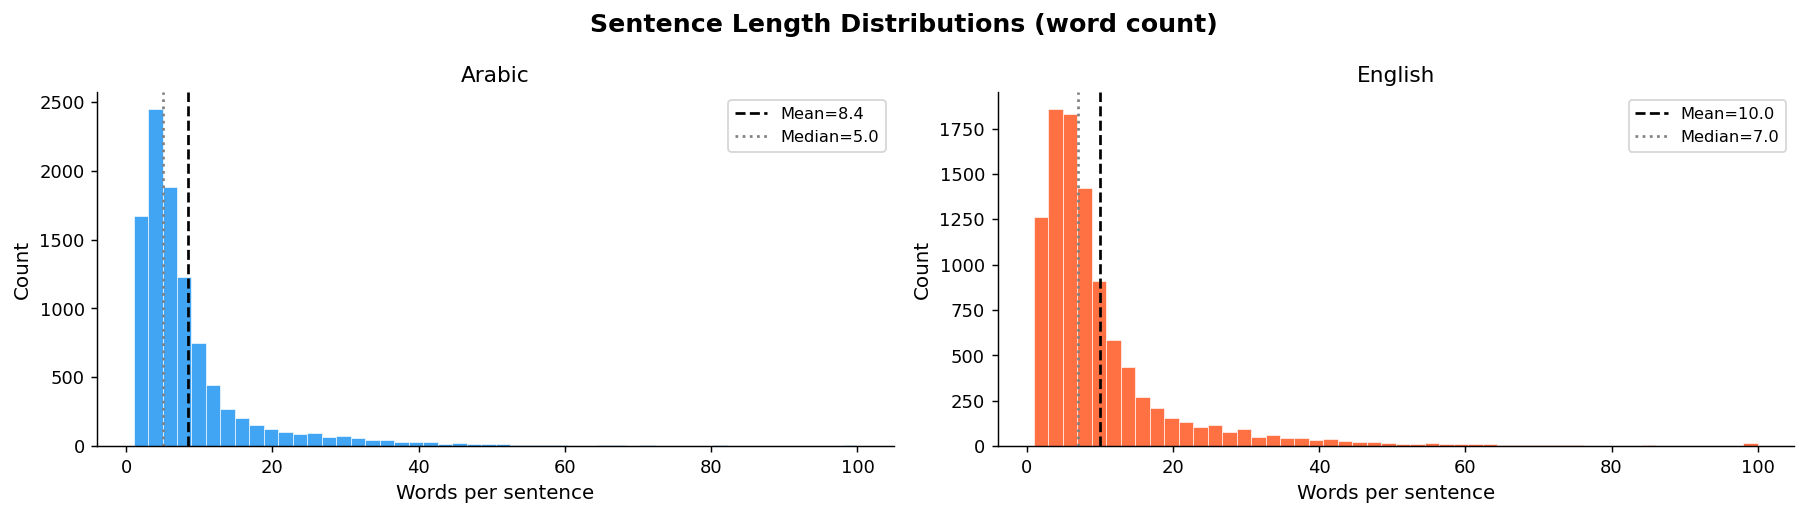

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Sentence Length Distributions (word count)', fontsize=14, fontweight='bold')

for ax, col, label, color in zip(
    axes,
    ['ar_len', 'en_len'],
    ['Arabic', 'English'],
    PALETTE
):
    data = df_eda[col].clip(upper=100)
    ax.hist(data, bins=50, color=color, alpha=0.85, edgecolor='white', linewidth=0.4)
    ax.axvline(data.mean(),  color='black',  ls='--', lw=1.5, label=f'Mean={data.mean():.1f}')
    ax.axvline(data.median(), color='grey', ls=':',  lw=1.5, label=f'Median={data.median():.1f}')
    ax.set_xlabel('Words per sentence', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(label, fontsize=12)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('eda_length_dist.png', bbox_inches='tight')
plt.show()

# AR vs EN Length Scatter

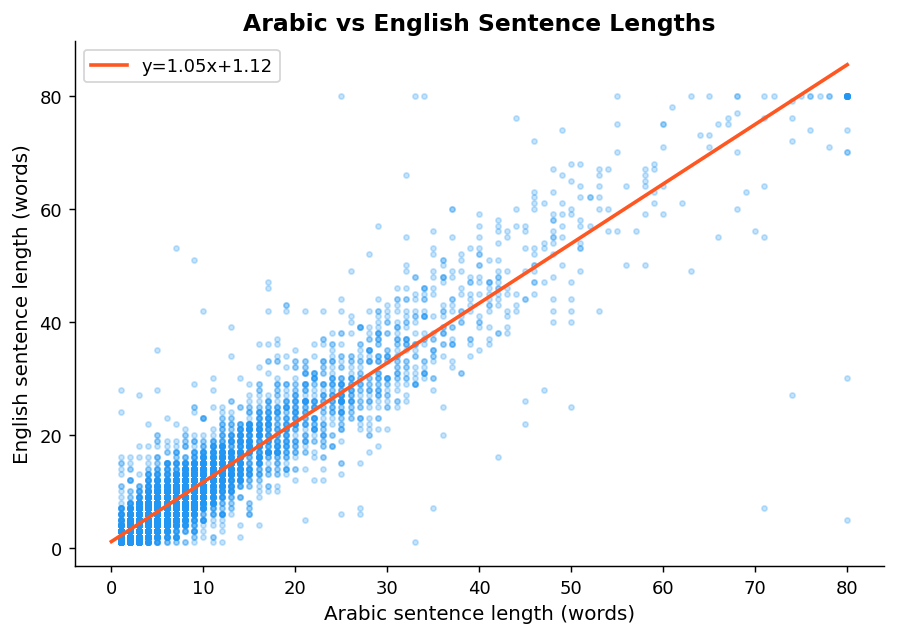

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df_eda['ar_len'].clip(upper=80),
           df_eda['en_len'].clip(upper=80),
           alpha=0.25, s=8, color=PALETTE[0])
ax.set_xlabel('Arabic sentence length (words)', fontsize=11)
ax.set_ylabel('English sentence length (words)', fontsize=11)
ax.set_title('Arabic vs English Sentence Lengths', fontsize=13, fontweight='bold')

# Regression line
m, b = np.polyfit(df_eda['ar_len'].clip(upper=80),
                  df_eda['en_len'].clip(upper=80), 1) # to find the best fit(slope,intercept)
x_range = np.linspace(0, 80, 100)
ax.plot(x_range, m*x_range + b, color=PALETTE[1], lw=2, label=f'y={m:.2f}x+{b:.2f}')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('eda_scatter.png', bbox_inches='tight')
plt.show()

# Top 30 Arabic & English Tokens

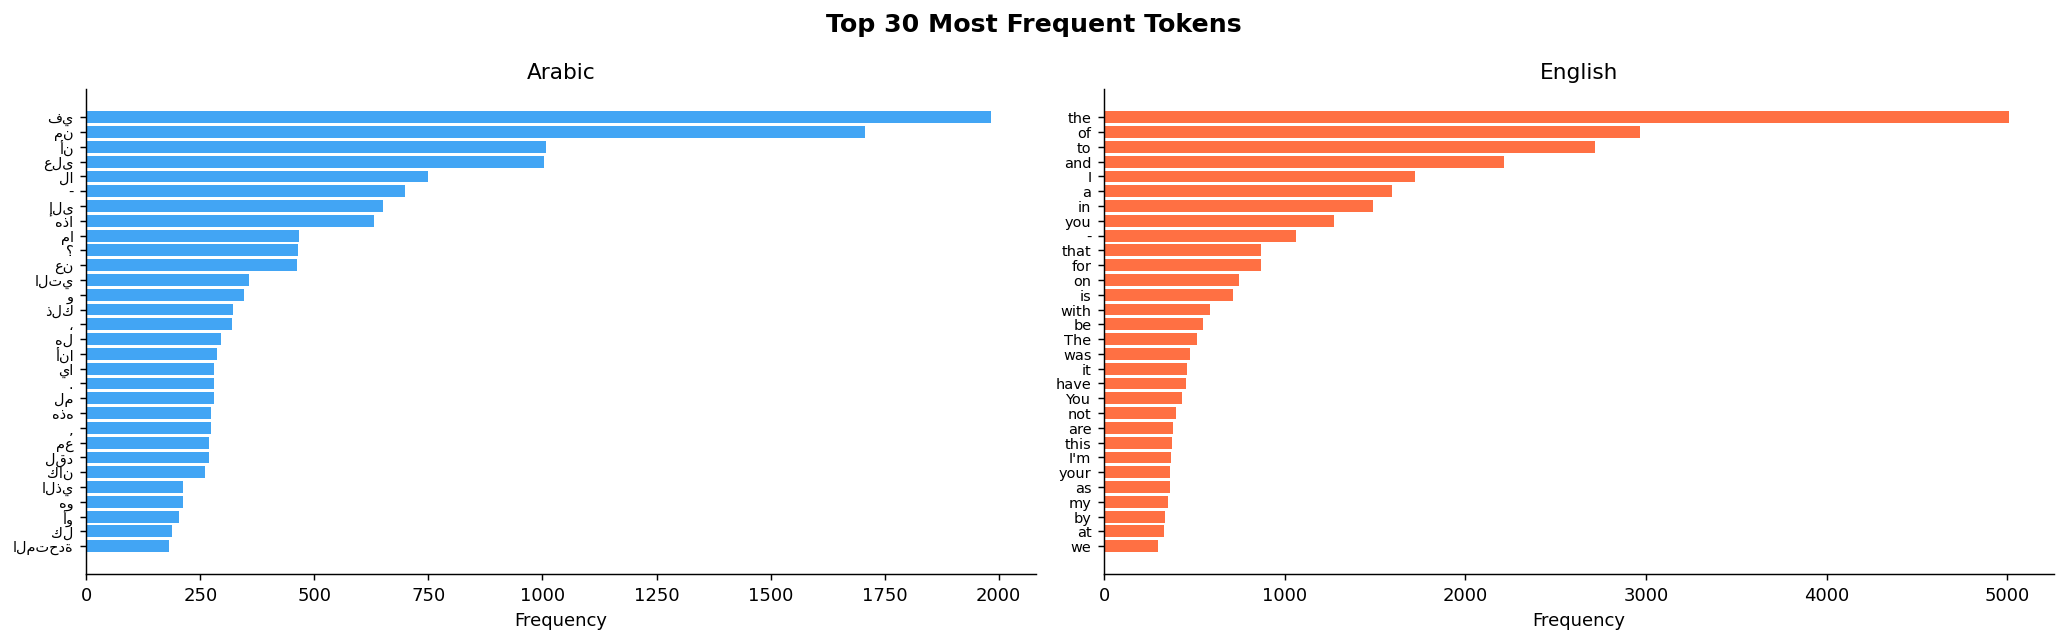

In [ ]:
def top_tokens(series, n=30):
    tokens = [t for sent in series for t in sent.split()]
    return pd.Series(Counter(tokens)).nlargest(n)

top_ar = top_tokens(df_eda['ar'])
top_en = top_tokens(df_eda['en'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Top 30 Most Frequent Tokens', fontsize=14, fontweight='bold')

for ax, top, title, color in zip(axes,
                                  [top_ar, top_en],
                                  ['Arabic', 'English'],
                                  [PALETTE[0], PALETTE[1]]):
    ax.barh(range(len(top)), top.values[::-1], color=color, alpha=0.85)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(top.index[::-1], fontsize=8)
    ax.set_xlabel('Frequency', fontsize=10)
    ax.set_title(title, fontsize=12)

plt.tight_layout()
plt.savefig('eda_top_tokens.png', bbox_inches='tight')
plt.show()

# Null / Empty pair analysis

In [ ]:
null_ar = df_eda['ar'].isna().sum() + (df_eda['ar'].str.strip() == '').sum()
null_en = df_eda['en'].isna().sum() + (df_eda['en'].str.strip() == '').sum()
dup     = df_eda.duplicated(subset=['ar', 'en']).sum()

print('=== Data Quality Report ===')
print(f'Empty Arabic sentences : {null_ar}')
print(f'Empty English sentences: {null_en}')
print(f'Duplicate pairs        : {dup}')
print(f'EDA subset size        : {len(df_eda):,}')

=== Data Quality Report ===
Empty Arabic sentences : 0
Empty English sentences: 0
Duplicate pairs        : 30
EDA subset size        : 10,000


---
## 4. Preprocessing

In [ ]:
#Text Cleaning 
# Arabic-specific Unicode ranges
ARABIC_DIACRITICS = re.compile(r'[\u0610-\u061A\u064B-\u065F\u0670\u06D6-\u06DC\u06DF-\u06E4\u06E7\u06E8\u06EA-\u06ED]')
ARABIC_TATWEEL    = re.compile(r'\u0640')                        # Kashida (جمــــيل---->جميل)
REPEATED_SPACES   = re.compile(r'\s{2,}')
URL_RE            = re.compile(r'https?://\S+|www\.\S+')
HTML_RE           = re.compile(r'<[^>]+>')

def clean_arabic(text: str) -> str:
    """Normalize Arabic text."""
    if not isinstance(text, str): return ''
    text = URL_RE.sub(' ', text)
    text = HTML_RE.sub(' ', text)
    text = ARABIC_DIACRITICS.sub('', text)   # remove tashkeel
    text = ARABIC_TATWEEL.sub('', text)       # remove tatweel/kashida
    # Normalise Alef variants → bare Alef
    text = re.sub('[\u0622\u0623\u0625]', '\u0627', text)
    # Normalise Teh Marbuta / Heh
    text = re.sub('[\u0629]', '\u0647', text)
    text = REPEATED_SPACES.sub(' ', text)
    return text.strip()

def clean_english(text: str) -> str:
    """Normalize English text."""
    if not isinstance(text, str): return ''
    text = URL_RE.sub(' ', text)
    text = HTML_RE.sub(' ', text)
    text = REPEATED_SPACES.sub(' ', text)
    return text.strip()

# Verify
ex_ar = 'الرَّحيمُ الرَّحْمَنُ  hello world'
print('Before:', ex_ar)
print('After :', clean_arabic(ex_ar))

Before: الرَّحيمُ الرَّحْمَنُ  hello world
After : الرحيم الرحمن hello world


In [ ]:
# Filter: remove pairs that are too short/long
MIN_LEN, MAX_LEN = 3, 128   

def is_valid_pair(example):
    ar = example['translation']['ar']
    en = example['translation']['en']
    ar_len = len(ar.split())
    en_len = len(en.split())
    return (
        ar_len >= MIN_LEN and en_len >= MIN_LEN and
        ar_len <= MAX_LEN and en_len <= MAX_LEN
    )

print('Filtering dataset...')
train_filtered = train_raw.filter(is_valid_pair, num_proc=2)
val_filtered   = val_raw.filter(is_valid_pair,   num_proc=2)
test_filtered  = test_raw.filter(is_valid_pair,  num_proc=2)

print(f'Train after filter : {len(train_filtered):,} (was {len(train_raw):,})')
print(f'Val   after filter : {len(val_filtered):,}')
print(f'Test  after filter : {len(test_filtered):,}')

Filtering dataset...


Filter (num_proc=2):   0%|          | 0/225000 [00:00<?, ? examples/s]

Filter (num_proc=2):   0%|          | 0/2000 [00:00<?, ? examples/s]

Filter (num_proc=2):   0%|          | 0/2000 [00:00<?, ? examples/s]

Train after filter : 180,271 (was 225,000)
Val   after filter : 1,718
Test  after filter : 1,739


# Load Tokenizer

In [ ]:
MODEL_NAME = 'Helsinki-NLP/opus-mt-ar-en'

tokenizer = MarianTokenizer.from_pretrained(MODEL_NAME)

MAX_INPUT_LEN  = 128
MAX_TARGET_LEN = 128

def preprocess_batch(examples):

    src_texts = [
        clean_arabic(ex['ar'])
        for ex in examples['translation']
    ]

    tgt_texts = [
        clean_english(ex['en'])
        for ex in examples['translation']
    ]

    # Encoder inputs
    model_inputs = tokenizer(
        src_texts,
        max_length=MAX_INPUT_LEN,
        truncation=True,
        padding=False
    )

    # Decoder targets
    labels = tokenizer(
        text_target=tgt_texts,
        max_length=MAX_TARGET_LEN,
        truncation=True,
        padding=False
    )

    model_inputs["labels"] = labels["input_ids"]

    return model_inputs

print('Tokenising...')

cols_to_remove = train_filtered.column_names

train_tok = train_filtered.map(
    preprocess_batch,
    batched=True,
    remove_columns=cols_to_remove,
    num_proc=2
)

val_tok = val_filtered.map(
    preprocess_batch,
    batched=True,
    remove_columns=cols_to_remove,
    num_proc=2
)

test_tok = test_filtered.map(
    preprocess_batch,
    batched=True,
    remove_columns=cols_to_remove,
    num_proc=2
)

print('Done.')
print(train_tok.features)

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/917k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

Tokenising...


Map (num_proc=2):   0%|          | 0/180271 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/1718 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/1739 [00:00<?, ? examples/s]

Done.
{'input_ids': List(Value('int32')), 'attention_mask': List(Value('int8')), 'labels': List(Value('int64'))}


# Token length distributions post-tokenization

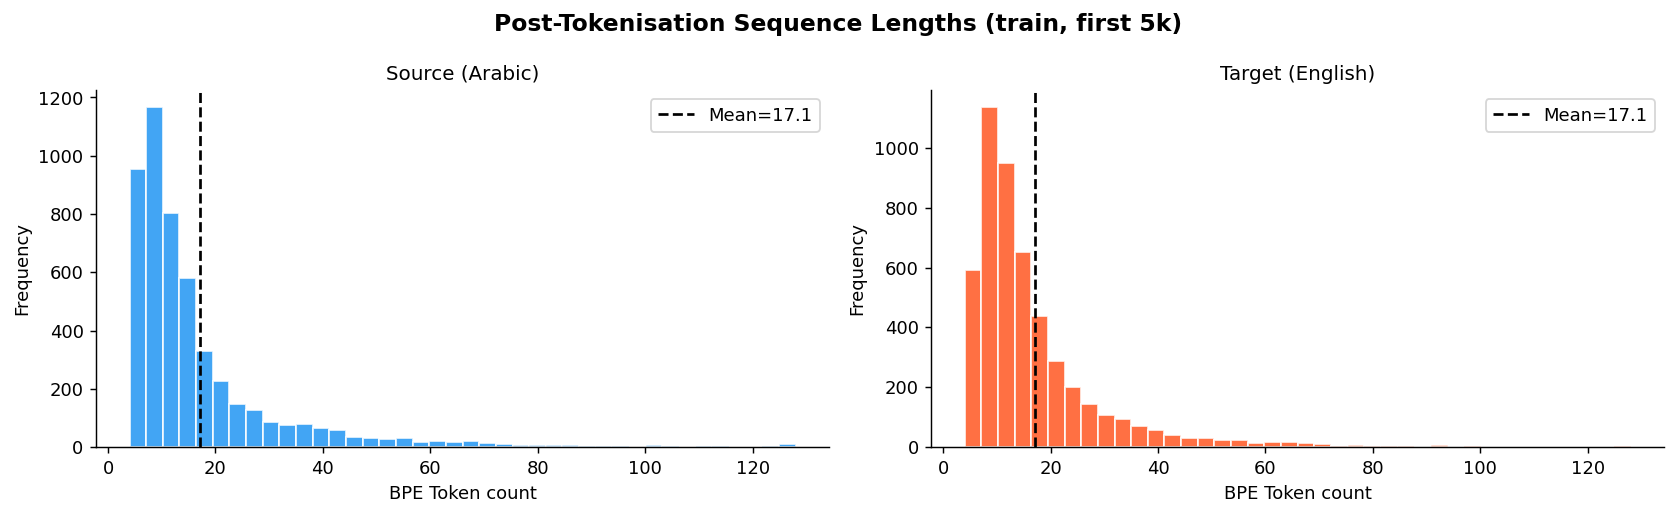

In [ ]:
src_lens = [len(x) for x in train_tok['input_ids'][:5000]]
tgt_lens = [len(x) for x in train_tok['labels'][:5000]]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Post-Tokenisation Sequence Lengths (train, first 5k)', fontsize=13, fontweight='bold')

for ax, lens, label, color in zip(axes,
                                    [src_lens, tgt_lens],
                                    ['Source (Arabic)', 'Target (English)'],
                                    PALETTE):
    ax.hist(lens, bins=40, color=color, alpha=0.85, edgecolor='white')
    ax.axvline(np.mean(lens), color='black', ls='--', lw=1.5,
               label=f'Mean={np.mean(lens):.1f}')
    ax.set_xlabel('BPE Token count', fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.set_title(label, fontsize=11)
    ax.legend()

plt.tight_layout()
plt.savefig('prep_token_lengths.png', bbox_inches='tight')
plt.show()

---
## 5. Model & Tokenizer

In [ ]:
# Load pre-trained MarianMT
model = MarianMTModel.from_pretrained(MODEL_NAME)
model = model.to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Model         : {MODEL_NAME}')
print(f'Total params  : {total_params:,}')
print(f'Trainable     : {trainable_params:,}')
print(f'Architecture  : {model.config.model_type}')
print(f'Encoder layers: {model.config.encoder_layers}')
print(f'Decoder layers: {model.config.decoder_layers}')
print(f'Hidden size   : {model.config.d_model}')
print(f'Vocab size    : {model.config.vocab_size}')

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/308M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


model.safetensors:   0%|          | 0.00/308M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

Model         : Helsinki-NLP/opus-mt-ar-en
Total params  : 141,175,808
Trainable     : 141,175,808
Architecture  : marian
Encoder layers: 6
Decoder layers: 6
Hidden size   : 512
Vocab size    : 62834


---
## 6. Training

In [ ]:
#Metric computation callback 
bleu_metric  = evaluate.load('sacrebleu')
chrf_metric  = evaluate.load('chrf')
rouge_metric = evaluate.load('rouge')

def compute_metrics(eval_preds):
    preds, labels = eval_preds

    # Replace -100 (padding) in labels
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)

    decoded_preds  = tokenizer.batch_decode(preds,   skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels,  skip_special_tokens=True)

    decoded_preds  = [p.strip() for p in decoded_preds]
    decoded_labels = [l.strip() for l in decoded_labels]

    # SacreBLEU
    bleu = bleu_metric.compute(
        predictions=decoded_preds,
        references=[[l] for l in decoded_labels]
    )['score']

    # ChrF
    chrf = chrf_metric.compute(
        predictions=decoded_preds,
        references=decoded_labels
    )['score']

    # ROUGE
    rouge = rouge_metric.compute(
        predictions=decoded_preds,
        references=decoded_labels
    )

    return {
        'bleu'  : round(bleu, 4),
        'chrf'  : round(chrf, 4),
        'rouge1': round(rouge['rouge1'], 4),
        'rouge2': round(rouge['rouge2'], 4),
        'rougeL': round(rouge['rougeL'], 4),
    }

In [ ]:
# Data Collator 
data_collator = DataCollatorForSeq2Seq(
    tokenizer,
    model=model,
    label_pad_token_id=-100,
    pad_to_multiple_of=8 if DEVICE == 'cuda' else None
)

#Training Arguments
OUTPUT_DIR = './ar_en_finetuned'

training_args = Seq2SeqTrainingArguments(
    output_dir=OUTPUT_DIR,

    # Training schedule
    num_train_epochs=5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    gradient_accumulation_steps=2,
    warmup_ratio=0.05,
    weight_decay=0.01,
    learning_rate=3e-5,
    lr_scheduler_type='cosine',
    fp16=torch.cuda.is_available(),

    # Generation during eval
    predict_with_generate=True,
    generation_max_length=MAX_TARGET_LEN,

    # Logging & evaluation
    eval_strategy='epoch',
    save_strategy='epoch',
    logging_strategy='steps',
    logging_steps=200,

    metric_for_best_model='bleu',
    greater_is_better=True,
    load_best_model_at_end=True,

    # Misc
    seed=SEED,
    report_to='none',
    save_total_limit=2,
)
# Trainer 
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,

    processing_class=tokenizer,

    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ]
)

print('Trainer ready. Starting training...')

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Trainer ready. Starting training...


In [ ]:
#Run Training 
train_result = trainer.train()
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

print('\n=== Training Summary ===')
print(f'Train runtime     : {train_result.metrics["train_runtime"]:.1f}s')
print(f'Samples/sec       : {train_result.metrics["train_samples_per_second"]:.1f}')
print(f'Final train loss  : {train_result.metrics["train_loss"]:.4f}')

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Epoch,Training Loss,Validation Loss,Bleu,Chrf,Rouge1,Rouge2,Rougel
1,5.216210,1.220361,43.765200,63.526300,0.667300,0.478700,0.651500
2,4.824387,1.218770,43.947300,63.633400,0.670600,0.483400,0.654400
3,4.599326,1.222632,43.659700,63.485900,0.669500,0.480900,0.653700
4,4.363235,1.224466,43.706100,63.481300,0.667200,0.479100,0.651300


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['model.encoder.embed_positions.weight', 'model.decoder.embed_positions.weight', 'lm_head.weight'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


=== Training Summary ===
Train runtime     : 7234.4s
Samples/sec       : 124.6
Final train loss  : 4.7411


---
## 7. Evaluation Metrics

| Metric | Description |
|---|---|
| **Training Loss** | Cross-entropy loss on the training set |
| **Validation Loss** | Cross-entropy loss on the validation set |
| **BLEU** | n-gram precision-based MT metric (SacreBLEU) |
| **ChrF** | Character n-gram F-score — robust for morphologically rich languages |
| **ROUGE-1** | Unigram overlap between prediction and reference |
| **ROUGE-2** | Bigram overlap |
| **ROUGE-L** | Longest common subsequence recall |

In [ ]:
log_history = trainer.state.log_history

# Training step losses
train_steps = [(e['step'], e['loss']) for e in log_history if 'loss' in e and 'eval_loss' not in e]

# Validation epoch metrics
eval_epochs = [e for e in log_history if 'eval_loss' in e]

# Build metrics table
metrics_rows = []
for e in eval_epochs:
    metrics_rows.append({
        'Epoch'          : e.get('epoch', '—'),
        'Train Loss'     : '—',          # filled below
        'Val Loss'       : round(e.get('eval_loss', float('nan')), 4),
        'BLEU'           : round(e.get('eval_bleu',   0), 4),
        'ChrF'           : round(e.get('eval_chrf',   0), 4),
        'ROUGE-1'        : round(e.get('eval_rouge1', 0), 4),
        'ROUGE-2'        : round(e.get('eval_rouge2', 0), 4),
        'ROUGE-L'        : round(e.get('eval_rougeL', 0), 4),
    })

# Attach final train loss
train_loss_by_epoch = {}
for e in log_history:
    if 'loss' in e and 'epoch' in e:
        train_loss_by_epoch[round(e['epoch'])] = round(e['loss'], 4)

for row in metrics_rows:
    ep = round(row['Epoch'])
    row['Train Loss'] = train_loss_by_epoch.get(ep, '—')

df_metrics = pd.DataFrame(metrics_rows)
print('=== Per-Epoch Metrics Table ===')
display(df_metrics)

=== Per-Epoch Metrics Table ===


,Epoch,Train Loss,Val Loss,BLEU,ChrF,ROUGE-1,ROUGE-2,ROUGE-L
0,1.0,4.8841,1.2204,43.7652,63.5263,0.6673,0.4787,0.6515
1,2.0,4.5379,1.2188,43.9473,63.6334,0.6706,0.4834,0.6544
2,3.0,4.3447,1.2226,43.6597,63.4859,0.6695,0.4809,0.6537
3,4.0,4.3632,1.2245,43.7061,63.4813,0.6672,0.4791,0.6513


---
## 8. Training & Validation Loss Curves

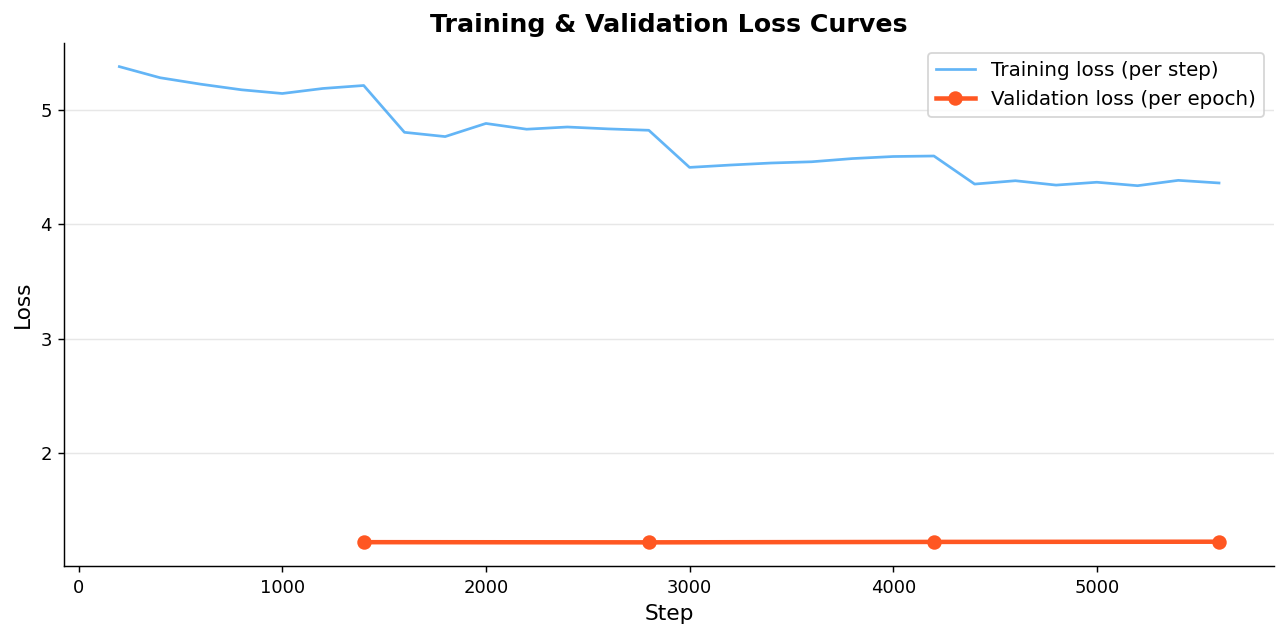

In [ ]:
# Loss Curves
steps, t_losses = zip(*train_steps) if train_steps else ([], [])
val_epochs_x  = [e.get('epoch') for e in eval_epochs]
val_losses    = [e.get('eval_loss') for e in eval_epochs]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(steps, t_losses, color=PALETTE[0], lw=1.5, alpha=0.7, label='Training loss (per step)')

# Map epoch → step for val points
steps_per_epoch = steps[-1] / len(val_epochs_x) if val_epochs_x else 1
val_steps = [e * steps_per_epoch for e in val_epochs_x]
ax.plot(val_steps, val_losses, color=PALETTE[1], lw=2.5,
        marker='o', markersize=7, label='Validation loss (per epoch)')

ax.set_xlabel('Step', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Training & Validation Loss Curves', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('loss_curves.png', bbox_inches='tight')
plt.show()

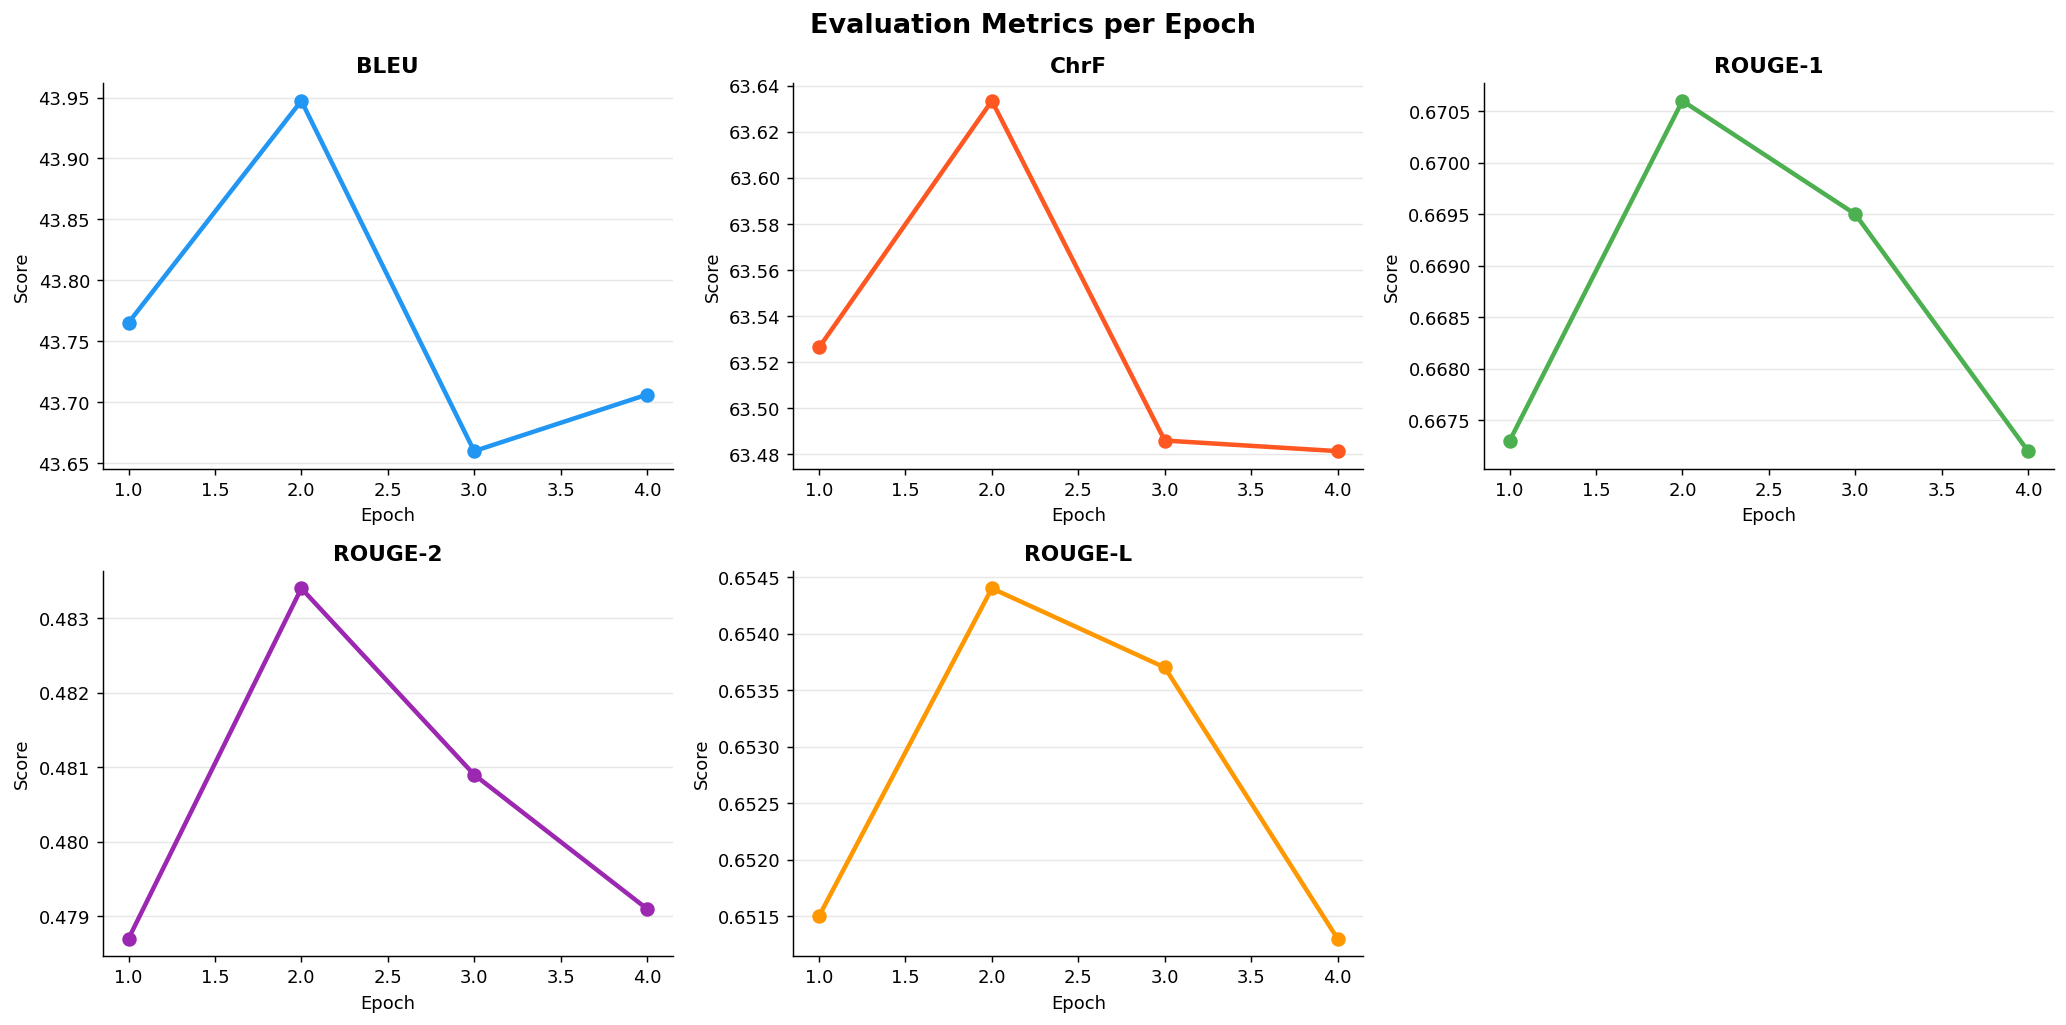

In [ ]:
# Metric curves across epochs 
metric_cols = ['BLEU', 'ChrF', 'ROUGE-1', 'ROUGE-2', 'ROUGE-L']
eval_col_map = {
    'BLEU':    'eval_bleu',
    'ChrF':    'eval_chrf',
    'ROUGE-1': 'eval_rouge1',
    'ROUGE-2': 'eval_rouge2',
    'ROUGE-L': 'eval_rougeL'
}

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Evaluation Metrics per Epoch', fontsize=15, fontweight='bold')
axes = axes.flatten()

for i, (name, key) in enumerate(eval_col_map.items()):
    vals = [e.get(key, 0) for e in eval_epochs]
    axes[i].plot(val_epochs_x, vals, color=PALETTE[i % len(PALETTE)],
                 lw=2.5, marker='o', markersize=7)
    axes[i].set_title(name, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Epoch', fontsize=10)
    axes[i].set_ylabel('Score', fontsize=10)
    axes[i].grid(axis='y', alpha=0.3)

axes[-1].set_visible(False)  # hide unused subplot
plt.tight_layout()
plt.savefig('metric_curves.png', bbox_inches='tight')
plt.show()

---
## 9. Evaluation on Test Set

In [ ]:
# Full test-set evaluation 
print('Running evaluation on test set...')
test_results = trainer.predict(test_tok)

test_metrics = test_results.metrics
print('\n=== Test Set Evaluation Results ===')
for k, v in test_metrics.items():
    if k.startswith('test_'):
        print(f'  {k:30s}: {v}')

# Decode predictions for later use
raw_preds = test_results.predictions
raw_labels = test_results.label_ids
raw_labels = np.where(raw_labels != -100, raw_labels, tokenizer.pad_token_id)

decoded_preds_test  = tokenizer.batch_decode(raw_preds,  skip_special_tokens=True)
decoded_labels_test = tokenizer.batch_decode(raw_labels, skip_special_tokens=True)
decoded_preds_test  = [p.strip() for p in decoded_preds_test]
decoded_labels_test = [l.strip() for l in decoded_labels_test]

# Beautiful table
result_df = pd.DataFrame([{
    'Metric': 'BLEU',   'Score': round(test_metrics.get('test_bleu',   0), 4)},
    {'Metric': 'ChrF',   'Score': round(test_metrics.get('test_chrf',   0), 4)},
    {'Metric': 'ROUGE-1','Score': round(test_metrics.get('test_rouge1', 0), 4)},
    {'Metric': 'ROUGE-2','Score': round(test_metrics.get('test_rouge2', 0), 4)},
    {'Metric': 'ROUGE-L','Score': round(test_metrics.get('test_rougeL', 0), 4)},
])
display(result_df.style.bar(subset=['Score'], color='#2196F3').format({'Score': '{:.4f}'}))

Running evaluation on test set...



=== Test Set Evaluation Results ===
  test_loss                     : 1.1895103454589844
  test_bleu                     : 43.0208
  test_chrf                     : 63.4346
  test_rouge1                   : 0.6642
  test_rouge2                   : 0.4781
  test_rougeL                   : 0.6474
  test_runtime                  : 137.8496
  test_samples_per_second       : 12.615
  test_steps_per_second         : 0.102


,Metric,Score
0,BLEU,43.0208
1,ChrF,63.4346
2,ROUGE-1,0.6642
3,ROUGE-2,0.4781
4,ROUGE-L,0.6474


---
## 10. BERTScore

In [ ]:
# BERTScore on test subset (first 500 for speed)
BERT_N = 500
print(f'Computing BERTScore on {BERT_N} test examples...')

P, R, F1 = bert_score_fn(
    decoded_preds_test[:BERT_N],
    decoded_labels_test[:BERT_N],
    lang='en',
    verbose=True
)

bert_p  = P.mean().item()
bert_r  = R.mean().item()
bert_f1 = F1.mean().item()

print(f'\n=== BERTScore (first {BERT_N} test examples) ===')
print(f'  Precision : {bert_p:.4f}')
print(f'  Recall    : {bert_r:.4f}')
print(f'  F1        : {bert_f1:.4f}')

bert_df = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'F1'],
    'BERTScore': [bert_p, bert_r, bert_f1]
})
display(bert_df.style
        .bar(subset=['BERTScore'], color='#4CAF50')
        .format({'BERTScore': '{:.4f}'}))

Computing BERTScore on 500 test examples...


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

  0%|          | 0/15 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/8 [00:00<?, ?it/s]

done in 4.56 seconds, 109.57 sentences/sec

=== BERTScore (first 500 test examples) ===
  Precision : 0.9523
  Recall    : 0.9462
  F1        : 0.9492


,Metric,BERTScore
0,Precision,0.9523
1,Recall,0.9462
2,F1,0.9492


---
## 11. BERTScore Distribution Plot (Test Subset)

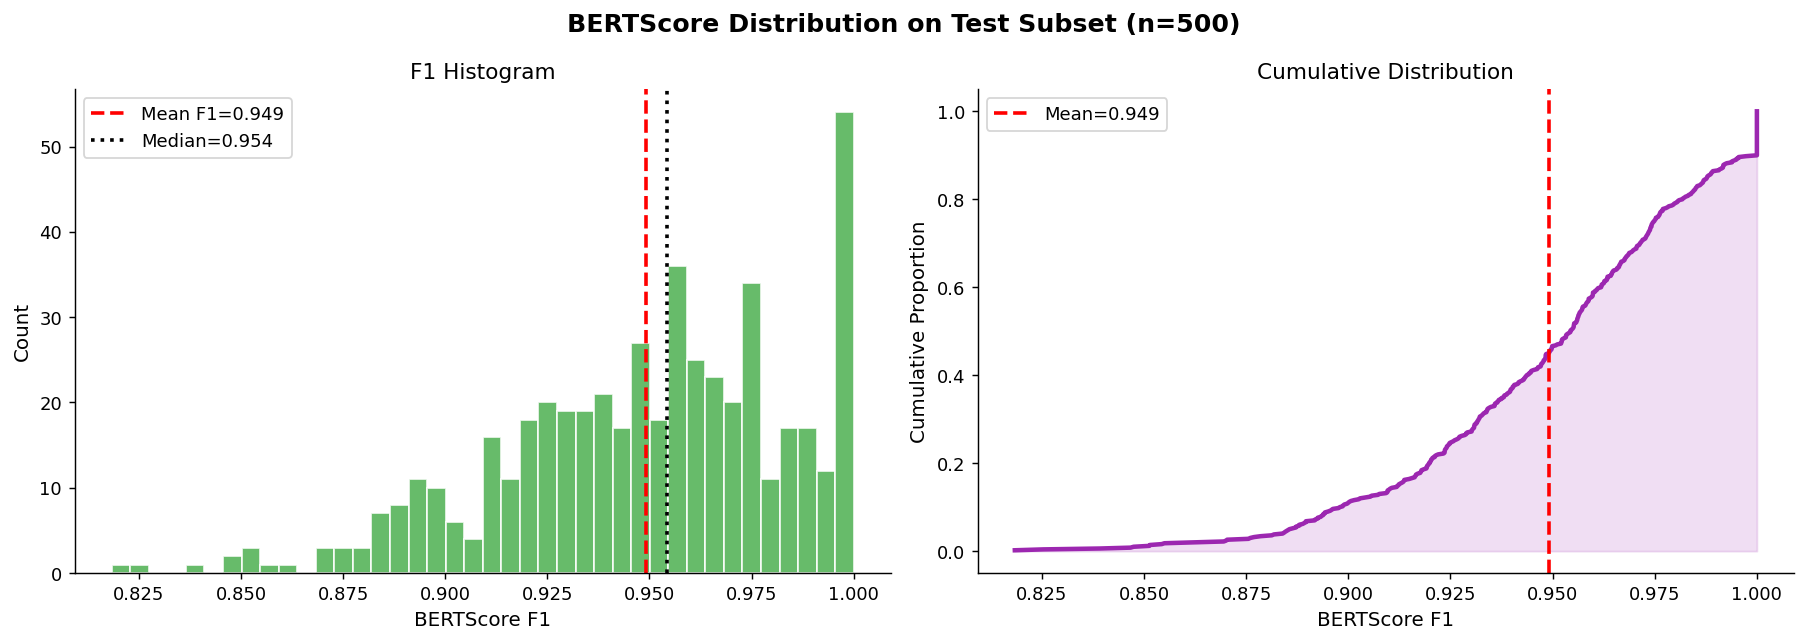

BERTScore F1 — Mean: 0.9492 | Std: 0.0357 | Min: 0.8184 | Max: 1.0000


In [27]:
# ── BERTScore F1 distribution ─────────────────────────────────────────────────
f1_scores = F1.numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'BERTScore Distribution on Test Subset (n={BERT_N})',
             fontsize=14, fontweight='bold')

# Histogram
ax = axes[0]
ax.hist(f1_scores, bins=40, color=PALETTE[2], alpha=0.85, edgecolor='white')
ax.axvline(bert_f1, color='red', ls='--', lw=2, label=f'Mean F1={bert_f1:.3f}')
ax.axvline(np.median(f1_scores), color='black', ls=':', lw=2,
           label=f'Median={np.median(f1_scores):.3f}')
ax.set_xlabel('BERTScore F1', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('F1 Histogram', fontsize=12)
ax.legend()

# KDE + CDF
ax2 = axes[1]
sorted_f1 = np.sort(f1_scores)
cdf = np.arange(1, len(sorted_f1)+1) / len(sorted_f1)
ax2.plot(sorted_f1, cdf, color=PALETTE[3], lw=2.5)
ax2.axvline(bert_f1, color='red', ls='--', lw=2, label=f'Mean={bert_f1:.3f}')
ax2.fill_between(sorted_f1, cdf, alpha=0.15, color=PALETTE[3])
ax2.set_xlabel('BERTScore F1', fontsize=11)
ax2.set_ylabel('Cumulative Proportion', fontsize=11)
ax2.set_title('Cumulative Distribution', fontsize=12)
ax2.legend()

plt.tight_layout()
plt.savefig('bertscore_distribution.png', bbox_inches='tight')
plt.show()

print(f'BERTScore F1 — Mean: {f1_scores.mean():.4f} | '
      f'Std: {f1_scores.std():.4f} | '
      f'Min: {f1_scores.min():.4f} | '
      f'Max: {f1_scores.max():.4f}')

---
## 12. Error Analysis

In [ ]:
# Build per-sentence BLEU and BERTScore for error analysis
from sacrebleu.metrics import BLEU as SacreBLEU_

_bleu = SacreBLEU_(effective_order=True)

per_sent = []
for pred, ref, bs in zip(
    decoded_preds_test[:BERT_N],
    decoded_labels_test[:BERT_N],
    f1_scores
):
    sent_bleu = _bleu.sentence_score(pred, [ref]).score
    per_sent.append({
        'prediction': pred,
        'reference' : ref,
        'bleu'      : round(sent_bleu, 2),
        'bert_f1'   : round(float(bs), 4),
        'pred_len'  : len(pred.split()),
        'ref_len'   : len(ref.split())
    })

df_err = pd.DataFrame(per_sent)
df_err['len_diff'] = df_err['pred_len'] - df_err['ref_len']

print('=== Error Analysis DataFrame (head 10) ===')
display(df_err.head(10))

=== Error Analysis DataFrame (head 10) ===


,prediction,reference,bleu,bert_f1,pred_len,ref_len,len_diff
0,And if it's not her?,What if it's not her?,75.98,0.9700,5,5,0
1,Ensuring security and credibility in Kabul and...,Ensuring credible security in Kabul and other ...,70.83,0.9877,13,12,1
2,"Wait, I already bought it.","""Wait, I bought it...",30.90,0.9338,5,4,1
3,Just add up the different classes of money pre...,"Just, uh, lining up all the presidents, nice a...",4.29,0.8818,11,10,1
4,The members of the Working Group noted that as...,Members of the Working Group have pointed out ...,16.69,0.9471,22,21,1
5,Come and live with us.,Come and have dinner with us.,32.16,0.9582,5,6,-1
6,Every year you're all right.,Happy New Year!,0.00,0.8514,5,3,2
7,- You see this?,- See that?,12.70,0.9605,4,3,1
8,"- Tell me. - Sorry, Jackie.","- All right, all right, all right. Here we go.",3.87,0.8769,6,10,-4
9,And you don't feel your performance is ready?,And you don't feel your performance is ready?,100.00,1.0000,8,8,0


# BLEU vs BERTScore scatter 

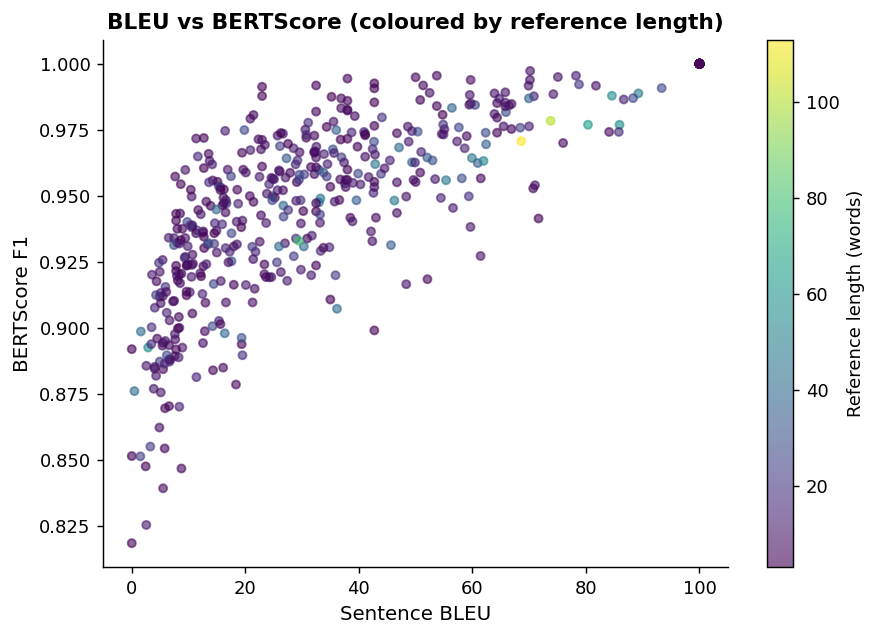

In [ ]:
# BLEU vs BERTScore scatter 
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(df_err['bleu'], df_err['bert_f1'],
                c=df_err['ref_len'], cmap='viridis', alpha=0.6, s=20)
plt.colorbar(sc, ax=ax, label='Reference length (words)')
ax.set_xlabel('Sentence BLEU', fontsize=11)
ax.set_ylabel('BERTScore F1', fontsize=11)
ax.set_title('BLEU vs BERTScore (coloured by reference length)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('error_bleu_vs_bert.png', bbox_inches='tight')
plt.show()

# Length deviation distribution 

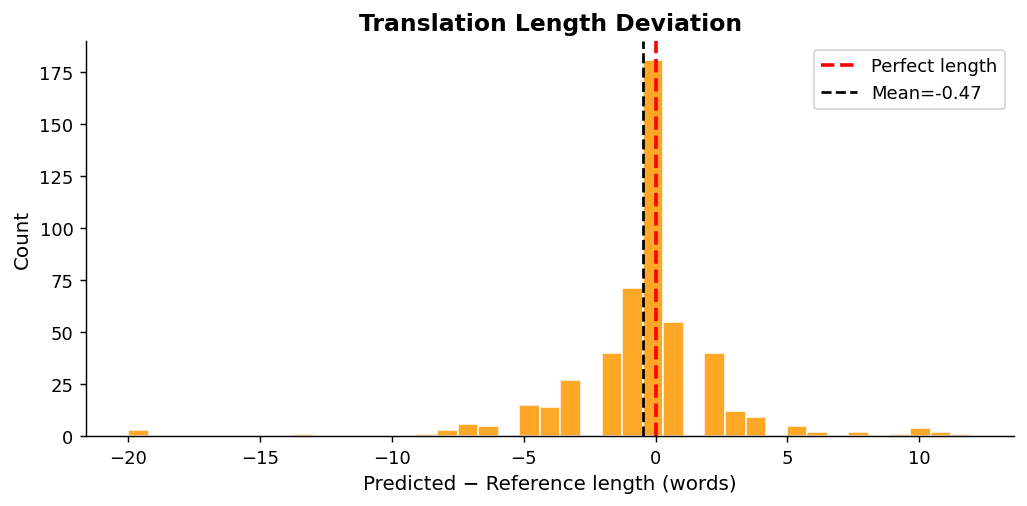

In [ ]:
# Length deviation distribution 
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df_err['len_diff'].clip(-20, 20), bins=41,
        color=PALETTE[4], alpha=0.85, edgecolor='white')
ax.axvline(0, color='red', ls='--', lw=2, label='Perfect length')
ax.axvline(df_err['len_diff'].mean(), color='black', ls='--', lw=1.5,
           label=f'Mean={df_err["len_diff"].mean():.2f}')
ax.set_xlabel('Predicted − Reference length (words)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Translation Length Deviation', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('error_len_deviation.png', bbox_inches='tight')
plt.show()

In [ ]:
# Worst translations (low BLEU)
print('\n=== Top 5 Worst Translations (lowest BLEU) ===')
worst = df_err.nsmallest(5, 'bleu')[['prediction','reference','bleu','bert_f1']]
for i, row in worst.iterrows():
    print(f'\n[BLEU={row["bleu"]:.1f} | BERTScore={row["bert_f1"]:.3f}]')
    print(f'  Pred: {row["prediction"]}')
    print(f'  Ref : {row["reference"]}')

# Best translations 
print('\n=== Top 5 Best Translations (highest BLEU) ===')
best = df_err.nlargest(5, 'bleu')[['prediction','reference','bleu','bert_f1']]
for i, row in best.iterrows():
    print(f'\n[BLEU={row["bleu"]:.1f} | BERTScore={row["bert_f1"]:.3f}]')
    print(f'  Pred: {row["prediction"]}')
    print(f'  Ref : {row["reference"]}')


=== Top 5 Worst Translations (lowest BLEU) ===

[BLEU=0.0 | BERTScore=0.851]
  Pred: Every year you're all right.
  Ref : Happy New Year!

[BLEU=0.0 | BERTScore=0.818]
  Pred: It's okay, sweetheart.
  Ref : T: S O K

[BLEU=0.0 | BERTScore=0.892]
  Pred: The Phantom of the Apache Desert.
  Ref : apache desert ghost

[BLEU=0.5 | BERTScore=0.876]
  Pred: The Higher Council commissioned the advisory body to study the following new topics:
  Ref : With regard to the subject of women and the economic, social and family role they play, the Supreme Council considered the views put forward by the Consultative Commission and decided to refer them to the bodies with competence for that subject.

[BLEU=1.5 | BERTScore=0.851]
  Pred: At the 11th meeting, on 21 September 2007, the moderator summarized the discussions and made her concluding remarks.
  Ref : The draft resolution, as orally revised, was adopted without a vote. For the text as adopted, see part one, chapter I, resolution 6/33.

=== To

# BLEU score bucket distribution

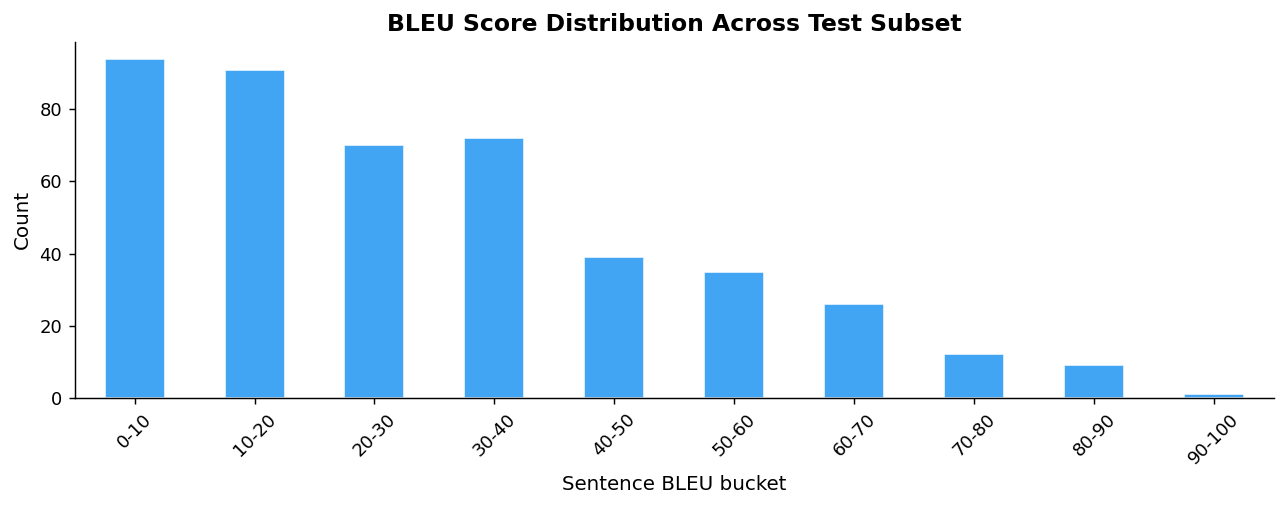

In [ ]:
# BLEU score bucket distribution
bins   = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
labels = [f'{b}-{b+10}' for b in bins[:-1]]
df_err['bleu_bucket'] = pd.cut(df_err['bleu'], bins=bins, labels=labels, right=False)
bucket_counts = df_err['bleu_bucket'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 4))
bucket_counts.plot(kind='bar', ax=ax, color=PALETTE[0], alpha=0.85, edgecolor='white')
ax.set_xlabel('Sentence BLEU bucket', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('BLEU Score Distribution Across Test Subset', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('error_bleu_buckets.png', bbox_inches='tight')
plt.show()

---
## 13. Inference

In [39]:
# ── Inference helper ──────────────────────────────────────────────────────────
def translate(texts, model=model, tokenizer=tokenizer,
              num_beams=5, max_len=128):
    """
    Translate a list of Arabic strings to English.
    Returns a list of translated strings.
    """
    if isinstance(texts, str):
        texts = [texts]
    cleaned = [clean_arabic(t) for t in texts]
    inputs = tokenizer(cleaned, return_tensors='pt',
                       padding=True, truncation=True,
                       max_length=MAX_INPUT_LEN).to(DEVICE)
    with torch.no_grad():
        translated = model.generate(
            **inputs,
            num_beams=num_beams,
            max_length=max_len,
            early_stopping=True
        )
    return tokenizer.batch_decode(translated, skip_special_tokens=True)

# ── Demo translations ─────────────────────────────────────────────────────────
demo_sentences = [
    'مرحبا بكم في مؤتمر الذكاء الاصطناعي السنوي.',
    'تحتل مصر مكانة بارزة في تاريخ الحضارة الإنسانية.',
    'يعتبر التعلم الآلي أحد أبرز مجالات تقنية المعلومات في العصر الحديث.',
    'الأسرة هي اللبنة الأساسية في بناء المجتمع.',
    'يسعدنا الإعلان عن إطلاق منتجنا الجديد في الأسواق العالمية.',
    'أصبحت تقنيات الذكاء الاصطناعي والتعلم العميق تلعب دورًا محوريًا في تطوير الأنظمة الذكية الحديثة'
]

translations = translate(demo_sentences)

print('=== Inference Demo ===')
for ar, en in zip(demo_sentences, translations):
    print(f'\n  AR: {ar}')
    print(f'  EN: {en}')

=== Inference Demo ===

  AR: مرحبا بكم في مؤتمر الذكاء الاصطناعي السنوي.
  EN: Welcome to the annual AI conference.

  AR: تحتل مصر مكانة بارزة في تاريخ الحضارة الإنسانية.
  EN: Egypt occupies a prominent place in the history of human civilization.

  AR: يعتبر التعلم الآلي أحد أبرز مجالات تقنية المعلومات في العصر الحديث.
  EN: Autolearning is one of the most prominent areas of information technology in modern times.

  AR: الأسرة هي اللبنة الأساسية في بناء المجتمع.
  EN: The family is the building block of society.

  AR: يسعدنا الإعلان عن إطلاق منتجنا الجديد في الأسواق العالمية.
  EN: We are pleased to announce the launch of our new product into the world market.

  AR: أصبحت تقنيات الذكاء الاصطناعي والتعلم العميق تلعب دورًا محوريًا في تطوير الأنظمة الذكية الحديثة
  EN: Artificial intelligence and deep learning technologies have become central to the development of modern smart systems.


In [34]:
# ── Interactive single-sentence inference ────────────────────────────────────
user_text = 'يعمل الباحثون على تطوير نماذج لغوية كبيرة قادرة على فهم اللغة العربية.'  # change me!

result = translate(user_text)[0]
print(f'Arabic  : {user_text}')
print(f'English : {result}')

Arabic  : يعمل الباحثون على تطوير نماذج لغوية كبيرة قادرة على فهم اللغة العربية.
English : The researchers are developing large language models capable of understanding Arabic.


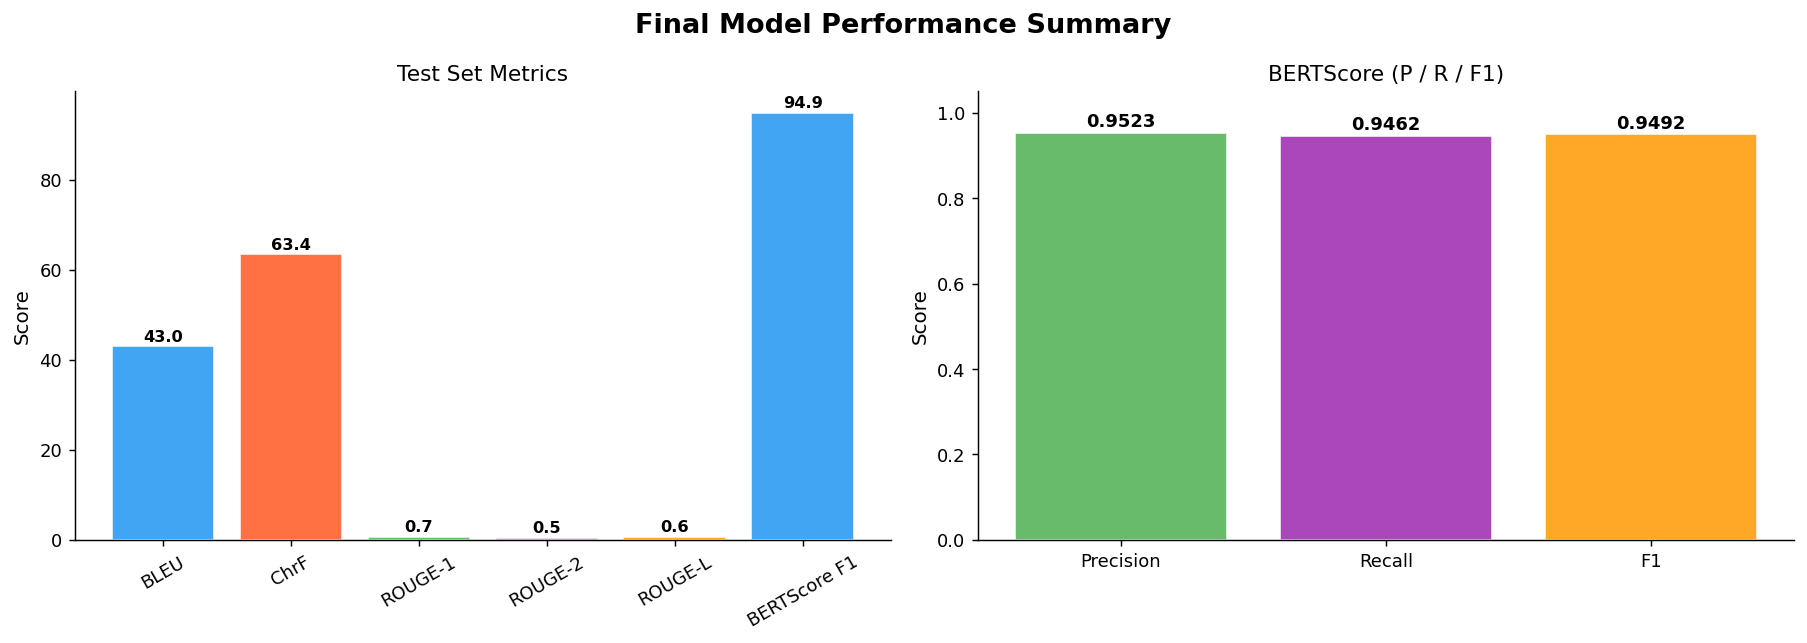


✅  All done! Model saved to: ./ar_en_finetuned


In [35]:
# ── Final Summary Dashboard ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Final Model Performance Summary', fontsize=15, fontweight='bold')

# Bar chart of all test metrics
metrics_names = ['BLEU', 'ChrF', 'ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'BERTScore F1']
metrics_values = [
    test_metrics.get('test_bleu',   0),
    test_metrics.get('test_chrf',   0),
    test_metrics.get('test_rouge1', 0),
    test_metrics.get('test_rouge2', 0),
    test_metrics.get('test_rougeL', 0),
    bert_f1 * 100   # scale to same range
]
colors = PALETTE[:len(metrics_names)]
bars = axes[0].bar(metrics_names, metrics_values, color=colors, alpha=0.85, edgecolor='white')
axes[0].set_ylabel('Score', fontsize=11)
axes[0].set_title('Test Set Metrics', fontsize=12)
axes[0].tick_params(axis='x', rotation=30)
for bar, val in zip(bars, metrics_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# BERTScore P/R/F1
bert_labels = ['Precision', 'Recall', 'F1']
bert_vals   = [bert_p, bert_r, bert_f1]
bars2 = axes[1].bar(bert_labels, bert_vals, color=PALETTE[2:5], alpha=0.85, edgecolor='white')
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel('Score', fontsize=11)
axes[1].set_title('BERTScore (P / R / F1)', fontsize=12)
for bar, val in zip(bars2, bert_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('final_summary_dashboard.png', bbox_inches='tight')
plt.show()

print('\n✅  All done! Model saved to:', OUTPUT_DIR)